In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df = pd.read_csv("train.csv")


In [3]:
df.head()


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


In [4]:
print("\n--- Dataset Info ---")
df.info()



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5847 non-null   int64  
 1   Name               5847 non-null   object 
 2   Location           5847 non-null   object 
 3   Year               5847 non-null   int64  
 4   Kilometers_Driven  5847 non-null   int64  
 5   Fuel_Type          5847 non-null   object 
 6   Transmission       5847 non-null   object 
 7   Owner_Type         5847 non-null   object 
 8   Mileage            5845 non-null   object 
 9   Engine             5811 non-null   object 
 10  Power              5811 non-null   object 
 11  Seats              5809 non-null   float64
 12  New_Price          815 non-null    object 
 13  Price              5847 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 639.6+ KB


In [5]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64


In [6]:
for col in df.columns:
    if df[col].dtype == 'O': 
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print("\n--- Missing Values After Imputation ---")
print(df.isnull().sum().sum())


--- Missing Values After Imputation ---
0


/var/folders/47/t16jhsbn4bd8hn2t5mzdrwrr0000gn/T/ipykernel_23169/1923467940.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/47/t16jhsbn4bd8hn2t5mzdrwrr0000gn/T/ipykernel_23169/1923467940.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

I chose to impute missing values instead of dropping rows because the dataset is large (5847 entries). Dropping would cause unnecessary data loss, while median/mode imputation preserves central tendencies and minimizes distortion.

In [7]:
def extract_numeric(x):
    if isinstance(x, str):
        return ''.join([c for c in x if c.isdigit() or c == '.'])
    return x

cols_to_clean = ['Mileage', 'Engine', 'Power', 'New_Price']
for col in cols_to_clean:
    df[col] = df[col].astype(str).apply(extract_numeric).replace('', np.nan).astype(float)

print("\n--- After Removing Units ---")
print(df[cols_to_clean].head())


--- After Removing Units ---
   Mileage  Engine   Power  New_Price
0    19.67  1582.0  126.20       4.78
1    13.00  1199.0   88.70       8.61
2    20.77  1248.0   88.76       4.78
3    15.20  1968.0  140.80       4.78
4    23.08  1461.0   63.10       4.78


In [8]:
categorical_cols = ['Fuel_Type', 'Transmission']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n--- Encoded Columns ---")
print([col for col in df_encoded.columns if 'Fuel_Type' in col or 'Transmission' in col])



--- Encoded Columns ---
['Fuel_Type_Electric', 'Fuel_Type_Petrol', 'Transmission_Manual']


In [9]:
current_year = datetime.now().year
df_encoded['Car_Age'] = current_year - df_encoded['Year']

print("\n--- New Feature Added ---")
print(df_encoded[['Year', 'Car_Age']].head())


--- New Feature Added ---
   Year  Car_Age
0  2015       10
1  2011       14
2  2012       13
3  2013       12
4  2013       12


In [10]:
print(df_encoded.columns.tolist())


['Unnamed: 0', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price', 'Price', 'Fuel_Type_Electric', 'Fuel_Type_Petrol', 'Transmission_Manual', 'Car_Age']


In [11]:
selected_df = df_encoded[['Name', 'Location', 'Price', 'Mileage', 'Engine', 'Power', 'Car_Age']]


In [12]:
filtered_df = selected_df[selected_df['Car_Age'] > 10]


In [13]:
renamed_df = filtered_df.rename(columns={'Price': 'Used_Car_Price'})


In [14]:
renamed_df['Price_per_BHP'] = renamed_df['Used_Car_Price'] / renamed_df['Power']


In [15]:
arranged_df = renamed_df.sort_values(by='Used_Car_Price', ascending=False)


In [16]:
summary = arranged_df.groupby('Name')['Used_Car_Price'].agg(['mean', 'count']).reset_index().sort_values('mean', ascending=False)

print("\n--- Summary (Average Price by Name) ---")
print(summary.head())


--- Summary (Average Price by Name) ---
                                                Name   mean  count
509                       Lamborghini Gallardo Coupe  120.0      1
814                   Mercedes-Benz SLK-Class 55 AMG   90.0      1
872                Porsche Panamera 2010 2013 Diesel   72.0      1
523  Land Rover Range Rover 3.6 TDV8 Vogue SE Diesel   70.0      1
527             Land Rover Range Rover TDV8 (Diesel)   67.0      1


/var/folders/47/t16jhsbn4bd8hn2t5mzdrwrr0000gn/T/ipykernel_23169/681316480.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary.head(10), x='Name', y='mean', palette='coolwarm', ax=ax)


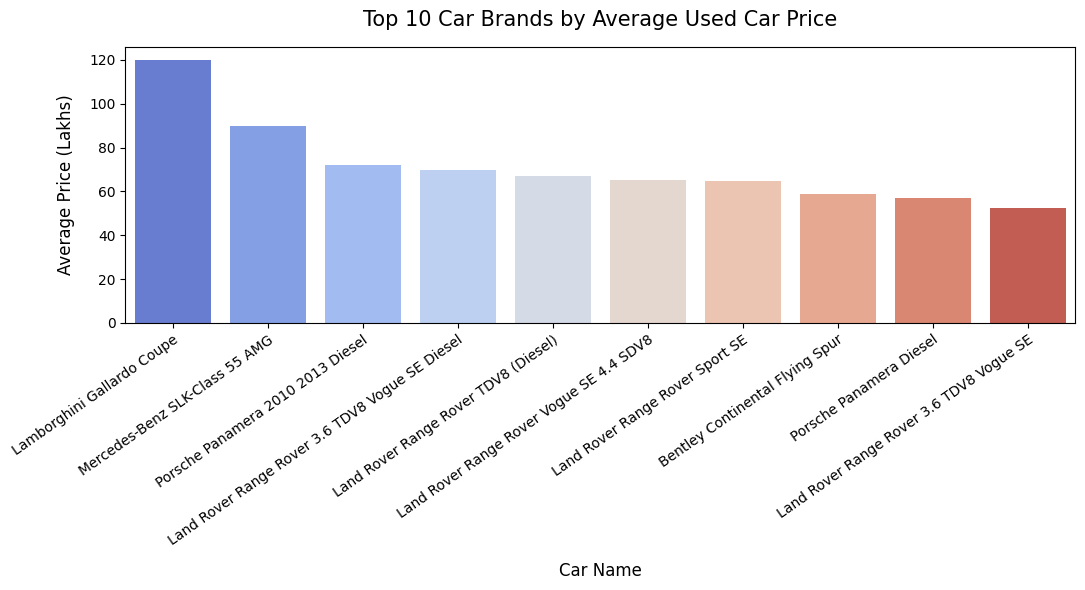

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("Images", exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=summary.head(10), x='Name', y='mean', palette='coolwarm', ax=ax)

ax.set_title('Top 10 Car Brands by Average Used Car Price', fontsize=15, pad=15)
ax.set_xlabel('Car Name', fontsize=12, labelpad=10)
ax.set_ylabel('Average Price (Lakhs)', fontsize=12, labelpad=10)

plt.setp(ax.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')

fig.tight_layout()

fig.savefig("Images/summary_groupby.png", bbox_inches='tight', dpi=300)

plt.show()


In [18]:
import os

output_csv = 'Q1_Cleaned_UsedCars.csv' 
image_dir = 'Images'

os.makedirs(image_dir, exist_ok=True)

df_encoded.to_csv('Q1_Cleaned_UsedCars.csv', index=False)


print(" Files saved successfully!")
print(f"CSV saved at: {output_csv}")
print(f"Chart saved in: {image_dir}")


 Files saved successfully!
CSV saved at: Q1_Cleaned_UsedCars.csv
Chart saved in: Images
